<a href="https://colab.research.google.com/github/tharakneo/hospital-readmission-prediction/blob/main/hospital_readmission_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loading Libraries**

In [3]:
# Install required libraries
!pip install -q imbalanced-learn

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_curve, roc_auc_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# **Data Loading and Preprocessing**

The dataset is loaded, cleaned (duplicates removed, placeholders replaced, and unnecessary columns dropped), and missing values are handled. Features are transformed, categorical variables encoded, and the dataset is split into X (features) and y (target).

In [4]:
# Load dataset
diabetic_data = pd.read_csv("diabetic_data.csv")

# Display columns to verify readmitted is present
print("Columns in diabetic_data:", diabetic_data.columns.tolist())

# Ensure readmitted column is present
if 'readmitted' not in diabetic_data.columns:
    raise ValueError("The 'readmitted' column is missing from the dataset.")

# Remove duplicate rows
diabetic_data.drop_duplicates(inplace=True)

# Replace placeholders with NaN
diabetic_data.replace('?', np.nan, inplace=True)

# Drop columns with too many missing values
cols_to_drop = ['encounter_id','patient_nbr','weight', 'payer_code', 'medical_specialty']
diabetic_data.drop(columns=cols_to_drop, inplace=True)

# Fill missing values for categorical columns
categorical_cols = ['race', 'diag_1', 'diag_2', 'diag_3']
for col in categorical_cols:
    diabetic_data[col] = diabetic_data[col].fillna('Unknown')

# Map age ranges to numerical values
age_mapping = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}
diabetic_data['age'] = diabetic_data['age'].map(age_mapping)

# Create binary target variable
diabetic_data['readmitted_binary'] = diabetic_data['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
diabetic_data.drop(columns=['readmitted'], inplace=True)

# Encode categorical variables using LabelEncoder
categorical_columns = diabetic_data.select_dtypes(include=['object']).columns.tolist()
label_encoder = LabelEncoder()
for col in categorical_columns:
    diabetic_data[col] = label_encoder.fit_transform(diabetic_data[col])

# Identify features and target
X = diabetic_data.drop(columns=['readmitted_binary'], errors='ignore')
y = diabetic_data['readmitted_binary']

Columns in diabetic_data: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


# **EDA**
We’ll use visualizations to explore how features like age, gender, and time in the hospital are distributed.

In [5]:
# Encode categorical variables using LabelEncoder
categorical_columns = diabetic_data.select_dtypes(include=['object']).columns.tolist()
label_encoder = LabelEncoder()
for col in categorical_columns:
    diabetic_data[col] = label_encoder.fit_transform(diabetic_data[col])

# Identify features and target
X = diabetic_data.drop(columns=['readmitted_binary'], errors='ignore')
y = diabetic_data['readmitted_binary']

Basic Statistical Description:
                race         gender            age  admission_type_id  \
count  101766.000000  101766.000000  101766.000000      101766.000000   
mean        1.732789       0.462443      65.967022           2.024006   
std         0.984989       0.498649      15.940838           1.445403   
min         0.000000       0.000000       5.000000           1.000000   
25%         2.000000       0.000000      55.000000           1.000000   
50%         2.000000       0.000000      65.000000           1.000000   
75%         2.000000       1.000000      75.000000           3.000000   
max         5.000000       2.000000      95.000000           8.000000   

       discharge_disposition_id  admission_source_id  time_in_hospital  \
count             101766.000000        101766.000000     101766.000000   
mean                   3.715642             5.754437          4.395987   
std                    5.280166             4.064081          2.985108   
min            

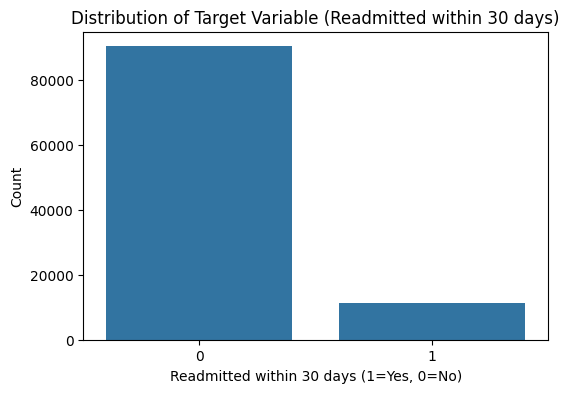

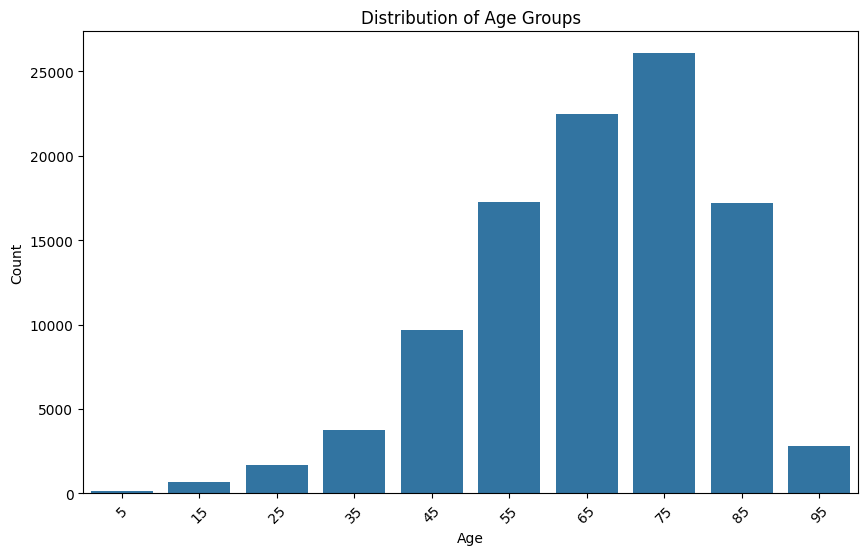

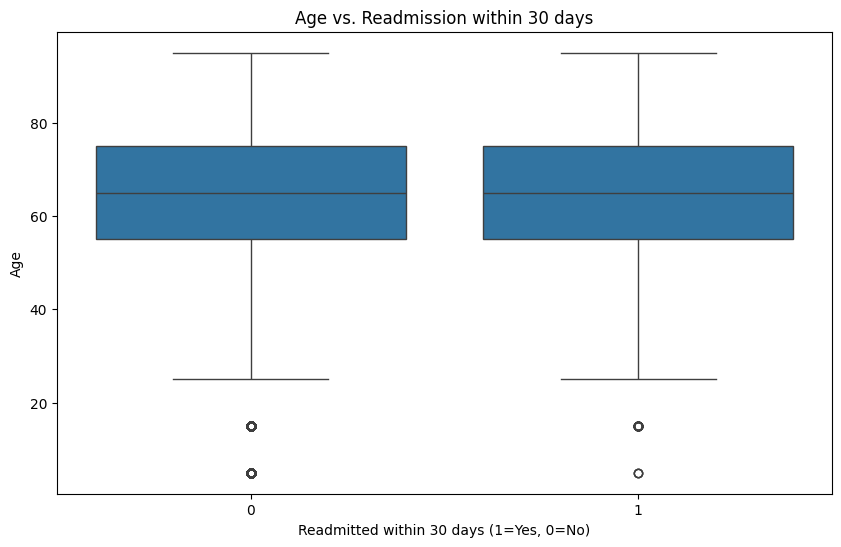

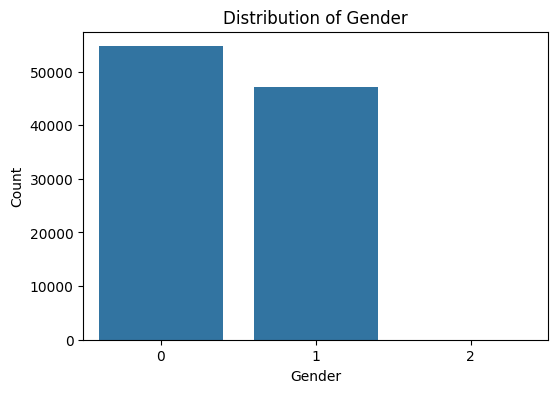

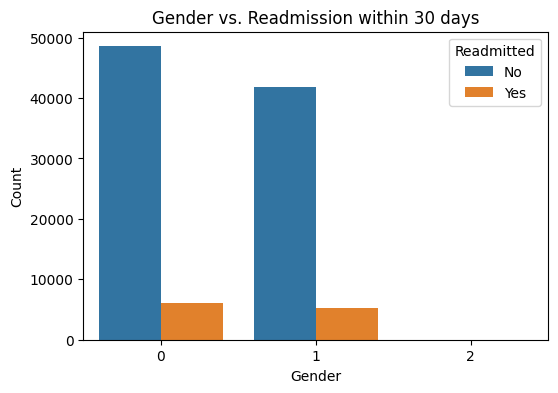

In [6]:
# EDA

import matplotlib.pyplot as plt
import seaborn as sns

# Display basic statistical description
print("Basic Statistical Description:")
print(diabetic_data.describe(include='all'))

# Check the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='readmitted_binary', data=diabetic_data)
plt.title('Distribution of Target Variable (Readmitted within 30 days)')
plt.xlabel('Readmitted within 30 days (1=Yes, 0=No)')
plt.ylabel('Count')
plt.show()

# Examine the distribution of age groups
plt.figure(figsize=(10, 6))
sns.countplot(x='age', data=diabetic_data, order=sorted(diabetic_data['age'].unique()))
plt.title('Distribution of Age Groups')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Explore the relationship between age and readmission
plt.figure(figsize=(10, 6))
sns.boxplot(x='readmitted_binary', y='age', data=diabetic_data)
plt.title('Age vs. Readmission within 30 days')
plt.xlabel('Readmitted within 30 days (1=Yes, 0=No)')
plt.ylabel('Age')
plt.show()

# Examine the distribution of gender
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=diabetic_data)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# Explore the relationship between gender and readmission
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', hue='readmitted_binary', data=diabetic_data)
plt.title('Gender vs. Readmission within 30 days')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Readmitted', labels=['No', 'Yes'])
plt.show()

# Correlation Heatmap (Numerical Columns Only)
# Select only numerical columns
numerical_columns = diabetic_data.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = diabetic_data[numerical_columns].corr()
correlation_with_target = correlation_matrix['readmitted_binary'].sort_values(ascending=False)


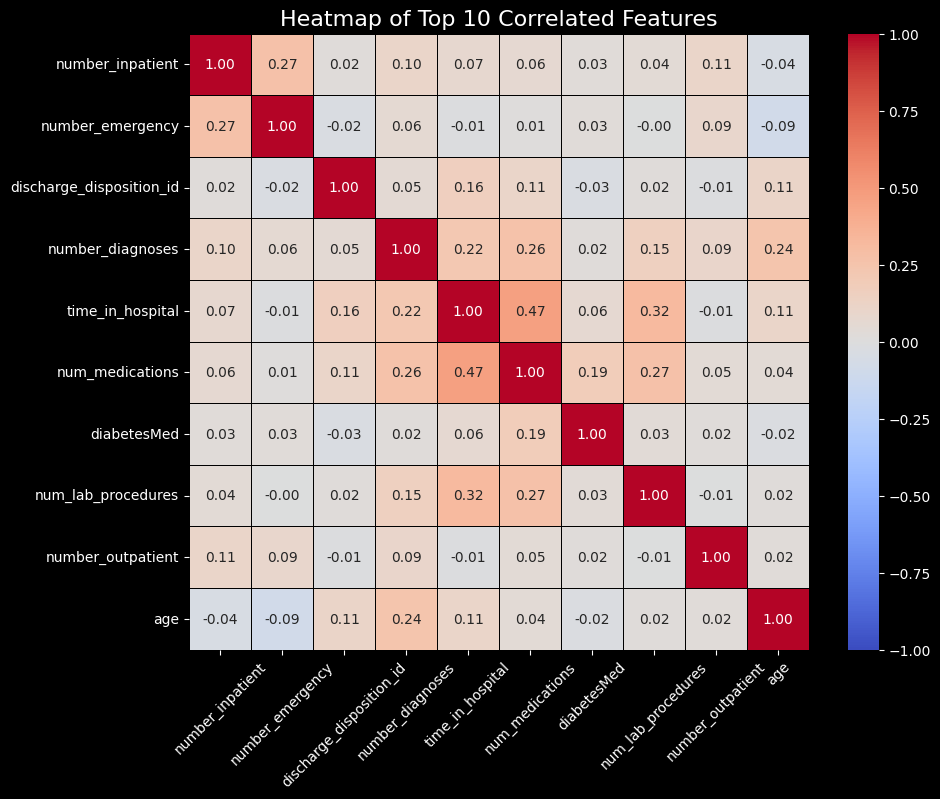

In [7]:
# Select top 10 features based on correlation with target
top_features = correlation_with_target[1:11].index
reduced_corr_matrix = correlation_matrix.loc[top_features, top_features]

#heatmap
plt.style.use('dark_background')
plt.figure(figsize=(10, 8))
sns.heatmap(
    reduced_corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='black'
)
plt.title('Heatmap of Top 10 Correlated Features', fontsize=16, color='white')
plt.xticks(rotation=45, fontsize=10, color='white')
plt.yticks(fontsize=10, color='white')
plt.show()

Features are standardized using MinMaxScaler to ensure all values are scaled between 0 and 1.

In [8]:
from sklearn.preprocessing import MinMaxScaler

# Standardize the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

# **Feature Selection**
Feature selection is performed using Chi-Square to select the top 10 most relevant features, which are then used to prepare the dataset for modeling.

In [9]:
# Feature Selection using Chi-Square
chi2_selector = SelectKBest(chi2, k=10)
X_kbest = chi2_selector.fit_transform(X, y)

# Get the selected feature names
mask = chi2_selector.get_support()
selected_features = X.columns[mask]
print("\nTop 10 Features Selected by Chi-Square:")
print(selected_features.tolist())

# Prepare data with selected features
X_selected = diabetic_data[selected_features]


Top 10 Features Selected by Chi-Square:
['admission_type_id', 'discharge_disposition_id', 'time_in_hospital', 'num_procedures', 'num_medications', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'change', 'diabetesMed']


Splitting the Data into Training and Testing Sets

In [10]:
# Split the Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, stratify=y, random_state=42)

# **Logistic Regression**
 Training, Evaluation, and Performance Analysis

In [11]:
rf = LogisticRegression(random_state = 42)
rf.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [12]:
# Logistic Regression
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

# Evaluate Logistic Regression
y_pred_lr = logistic_model.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("\nLogistic Regression Performance:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Performance:
Accuracy: 0.8884
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.50      0.01      0.03      2271

    accuracy                           0.89     20354
   macro avg       0.69      0.51      0.48     20354
weighted avg       0.85      0.89      0.84     20354



# **Decision Tree Classifier**
 Training, Evaluation, and Performance Analysis

In [13]:
rf = DecisionTreeClassifier(random_state = 42)
rf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [14]:
# Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Evaluate Decision Tree
y_pred_dt = dt_model.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("\nDecision Tree Classifier Performance:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(classification_report(y_test, y_pred_dt))


Decision Tree Classifier Performance:
Accuracy: 0.8171
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     18083
           1       0.17      0.17      0.17      2271

    accuracy                           0.82     20354
   macro avg       0.54      0.53      0.53     20354
weighted avg       0.82      0.82      0.82     20354



# **Random Forest Classifier**
Training, Evaluation, and Hyperparameter Tuning

In [15]:
rf = RandomForestClassifier(random_state = 42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [16]:
# Train Random Forest without hyperparameter tuning
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Evaluate Random Forest (without tuning) using the .score method
rf_acc = rf.score(X_test, y_test)
y_pred_rf = rf.predict(X_test)
rf_f1 = f1_score(y_test, y_pred_rf)

print("\nRandom Forest Classifier (Without Tuning) Performance:")
print(f"Accuracy: {rf_acc:.4f}")
print(f"F1-Score: {rf_f1:.4f}")
print(classification_report(y_test, y_pred_rf))


Random Forest Classifier (Without Tuning) Performance:
Accuracy: 0.8742
F1-Score: 0.0731
              precision    recall  f1-score   support

           0       0.89      0.98      0.93     18083
           1       0.21      0.04      0.07      2271

    accuracy                           0.87     20354
   macro avg       0.55      0.51      0.50     20354
weighted avg       0.81      0.87      0.84     20354



In [ ]:
# Random Forest Classifier with Hyperparameter Tuning
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid_rf,
    scoring='accuracy',
    cv=3,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
rf_model = rf_grid.best_estimator_

print(f"\nBest parameters for Random Forest: {rf_grid.best_params_}")

# Evaluate Random Forest
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("\nRandom Forest Classifier Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(classification_report(y_test, y_pred_rf))

# **Plotting and Comparing ROC Curves for Logistic Regression, Decision Tree, and Random Forest**

In [ ]:
# Plotting ROC Curves
y_pred_proba_lr = logistic_model.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title("ROC Curves", fontsize=16)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend()
plt.show()